In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz

In [48]:
url_transdata = "https://raw.githubusercontent.com/FIAP/Pos_Tech_DTAT/refs/heads/main/Fase%202/02%20-%20Machine%20Learning%20Avan%C3%A7ado/Aula%202/Base%20de%20Dados/card_transdata.csv"

In [49]:
card = pd.read_csv(url_transdata)
card.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [50]:
card.isnull().sum()

,0
distance_from_home,0
distance_from_last_transaction,0
ratio_to_median_purchase_price,0
repeat_retailer,0
used_chip,0
used_pin_number,0
online_order,0
fraud,0


In [51]:
card.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


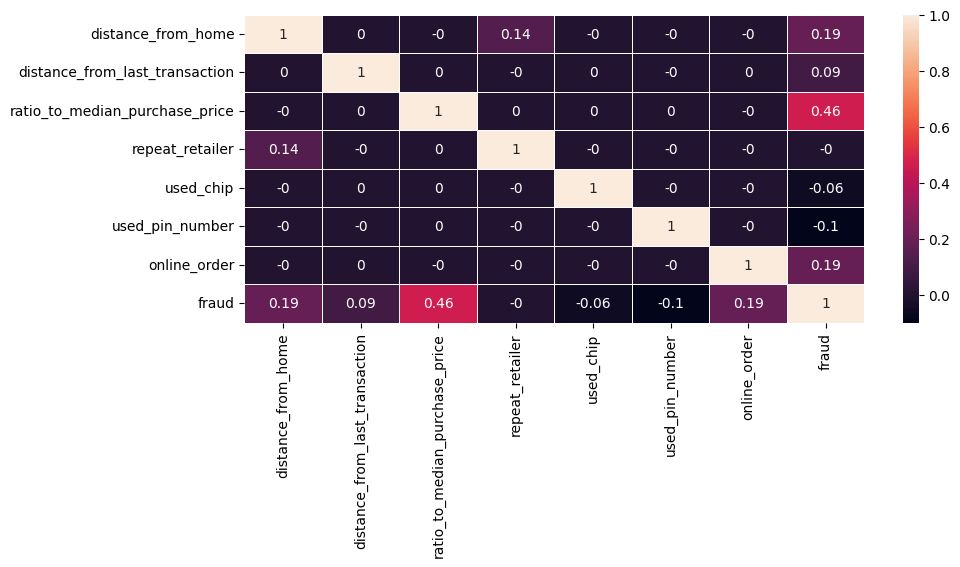

In [52]:
correlation = card.corr().round(2)
fig, ax = plt.subplots(figsize=(10,4))
sns.heatmap(data=correlation,annot=True,ax=ax,linewidths=0.5)
plt.show()

In [53]:
x = card.drop(columns=["fraud"]) #x usa as variáveis de entrada, o que o modelo usa para decidir
y = card["fraud"]#target, o que o modelo precisa aprender a prever

In [54]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=7)
#20% vai para teste e 80% vai para treino / o stratify serve para manter a mesma proporção de fraudes e não fraudes em treino e teste / random state garante que a divisao seja reproduzível

In [55]:
dt = DecisionTreeClassifier(random_state=7, criterion='entropy', max_depth = 2)
#entropy é a metrica usada para decidir os cortes da árvore/ max depth é a profundidade da árvore, evita overfitting

In [56]:
dt.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=7)

In [57]:
y_predito = dt.predict(x_test)

[Text(0.5, 0.8333333333333334, 'x[2] <= 4.0\nentropy = 0.428\nsamples = 800000\nvalue = [730078, 69922]'),
 Text(0.25, 0.5, 'x[0] <= 100.004\nentropy = 0.169\nsamples = 717444\nvalue = [699473, 17971]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'entropy = 0.052\nsamples = 681683\nvalue = [677647, 4036]'),
 Text(0.375, 0.16666666666666666, 'entropy = 0.965\nsamples = 35761\nvalue = [21826, 13935]'),
 Text(0.75, 0.5, 'x[6] <= 0.5\nentropy = 0.951\nsamples = 82556\nvalue = [30605.0, 51951.0]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'entropy = 0.541\nsamples = 29007\nvalue = [25406, 3601]'),
 Text(0.875, 0.16666666666666666, 'entropy = 0.46\nsamples = 53549\nvalue = [5199, 48350]')]

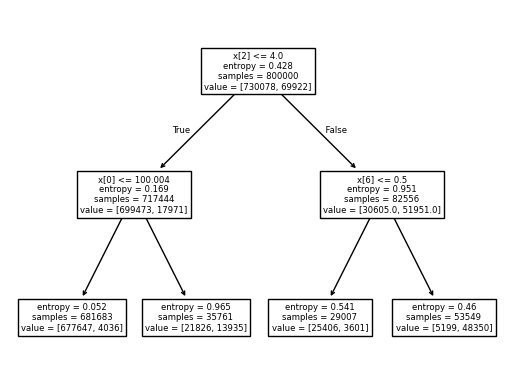

In [58]:
tree.plot_tree(dt)

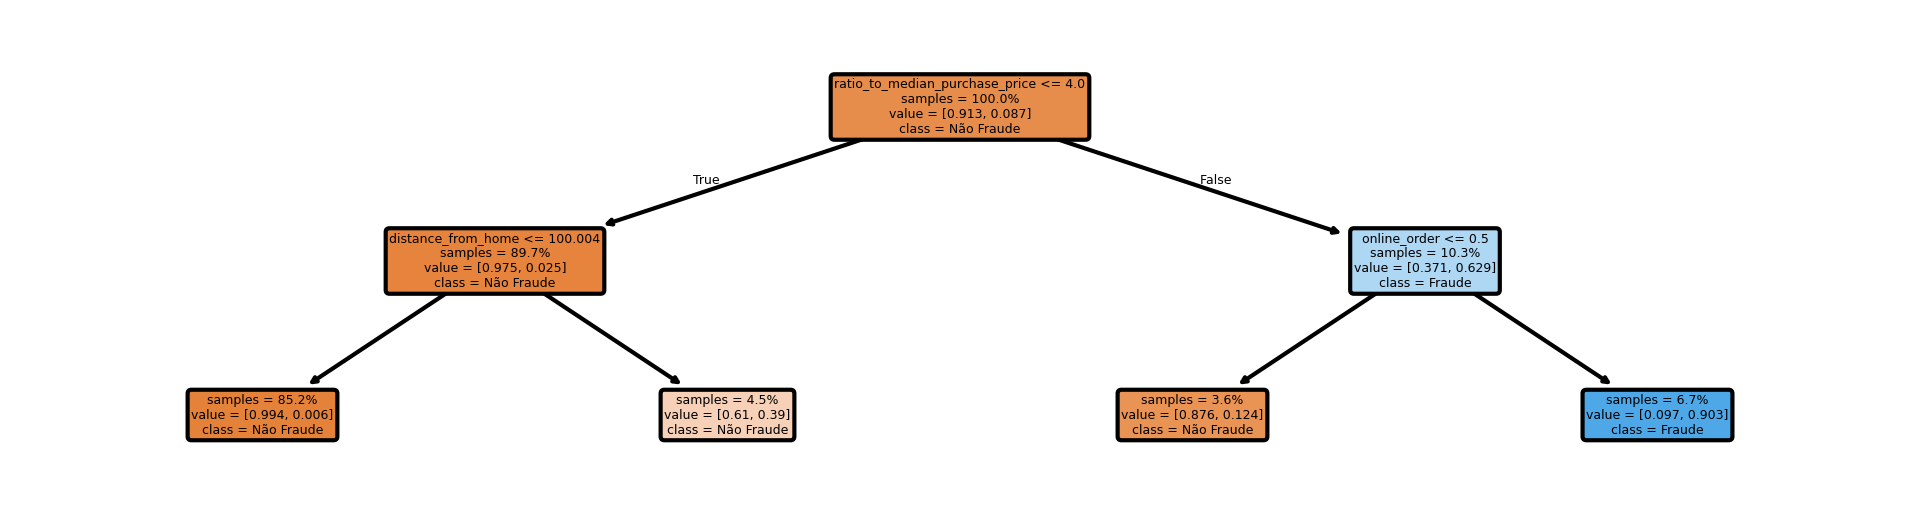

In [59]:
class_names = ['Não Fraude', 'Fraude']
label_names = ['distance_from_home', 'distance_from_last_transaction',	'ratio_to_median_purchase_price',	'repeat_retailer',	'used_chip',	'used_pin_number',	'online_order']

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (8,2), dpi=300)

tree.plot_tree(dt,
               feature_names = label_names,
               class_names=class_names,
               filled = True,
               rounded=True,
               max_depth=3,        # 🔑 ESSENCIAL
               impurity=False,     # remove entropy
               proportion=True,    # evita números gigantes
               fontsize=3)          # fonte pequena

fig.savefig('imagename.png')

In [60]:
print(accuracy_score(y_test, y_predito))

0.96675


Random Forest

In [61]:
rf = RandomForestClassifier(n_estimators=5, max_depth = 2,random_state=7) #número de árvores/ profundidade / reprodutividade
rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=2, n_estimators=5, random_state=7)

In [62]:
estimators = rf.estimators_
# rf.estimators_: lista com cada árvore treinada (cada uma é um DecisionTreeClassifier).
# Por quê? Para inspecionar/plotar árvores individuais.

In [63]:
y_predito_rf = rf.predict(x_test)

In [64]:
print(accuracy_score(y_test, y_predito_rf))

0.95339


In [65]:
class_names = ['Não Fraude', 'Fraude']
label_names = ['distance_from_home', 'distance_from_last_transaction','ratio_to_median_purchase_price','repeat_retailer','used_chip','used_pin_number','online_order']

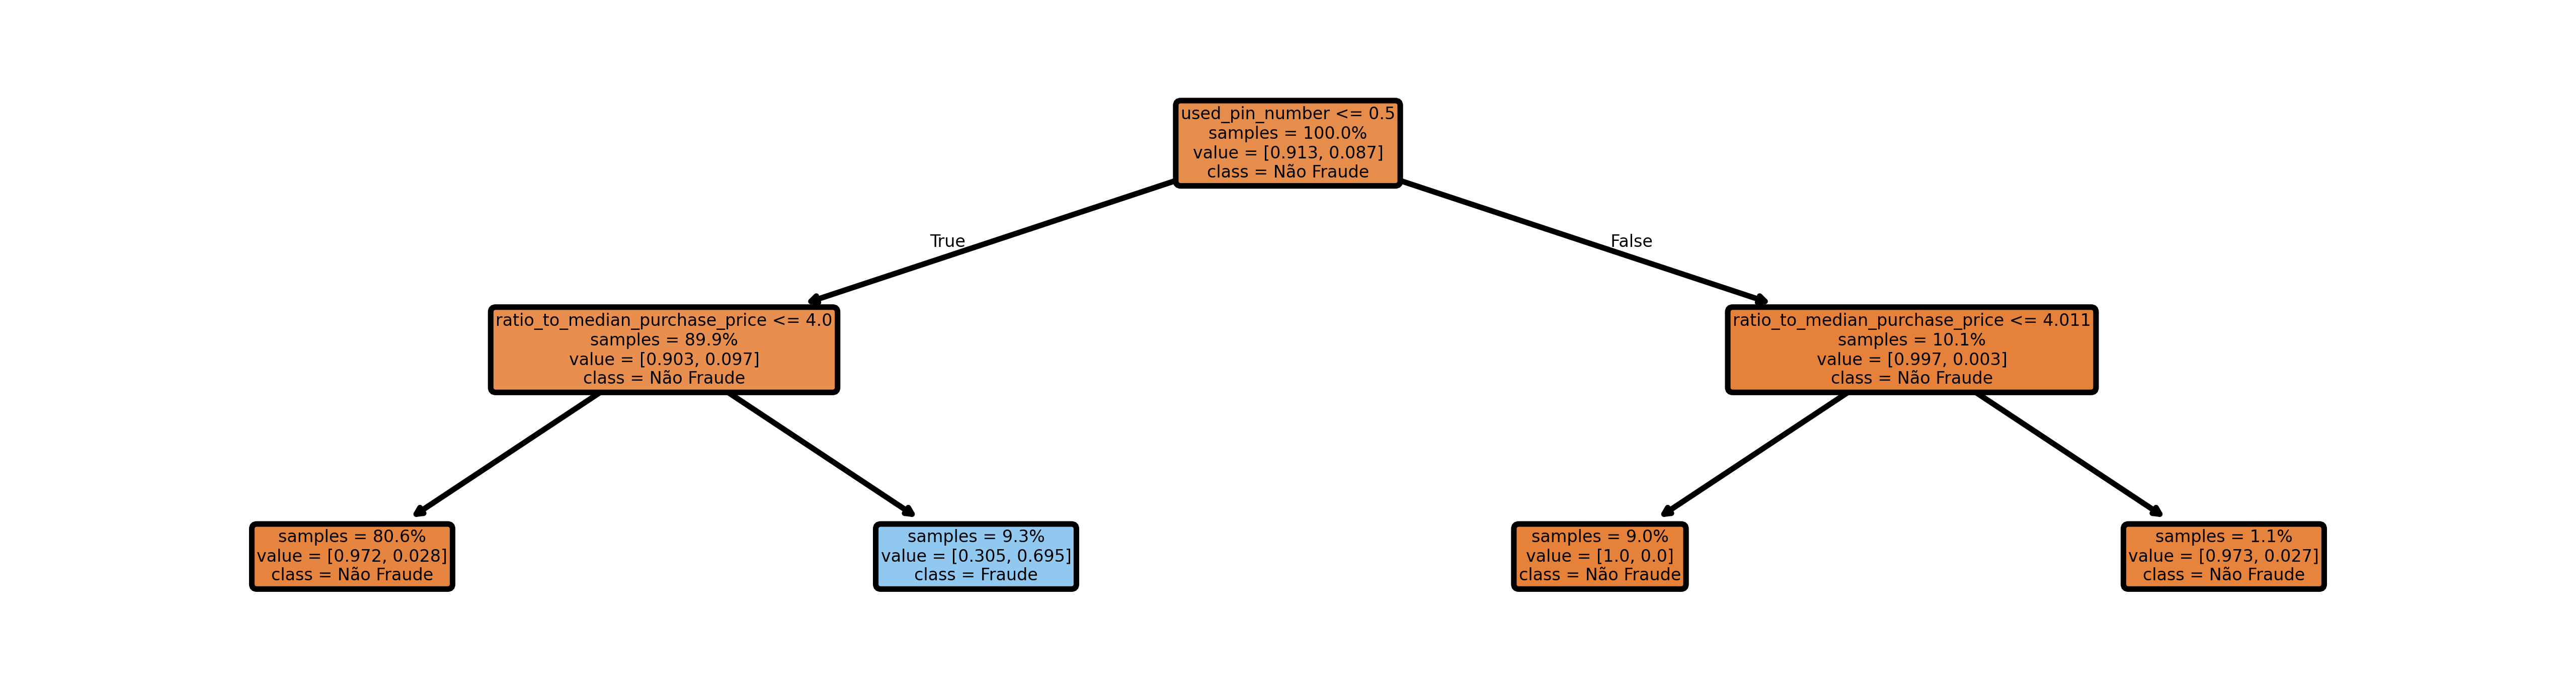

In [66]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (8,2), dpi=800)
tree.plot_tree(rf.estimators_[0],
               feature_names = label_names,
               class_names=class_names,
               filled = True,
               rounded=True,
               max_depth=3,        # 🔑 ESSENCIAL
               impurity=False,     # remove entropy
               proportion=True,    # evita números gigantes
               fontsize=3)          # fonte pequena
fig.savefig('rf_individualtree.png')

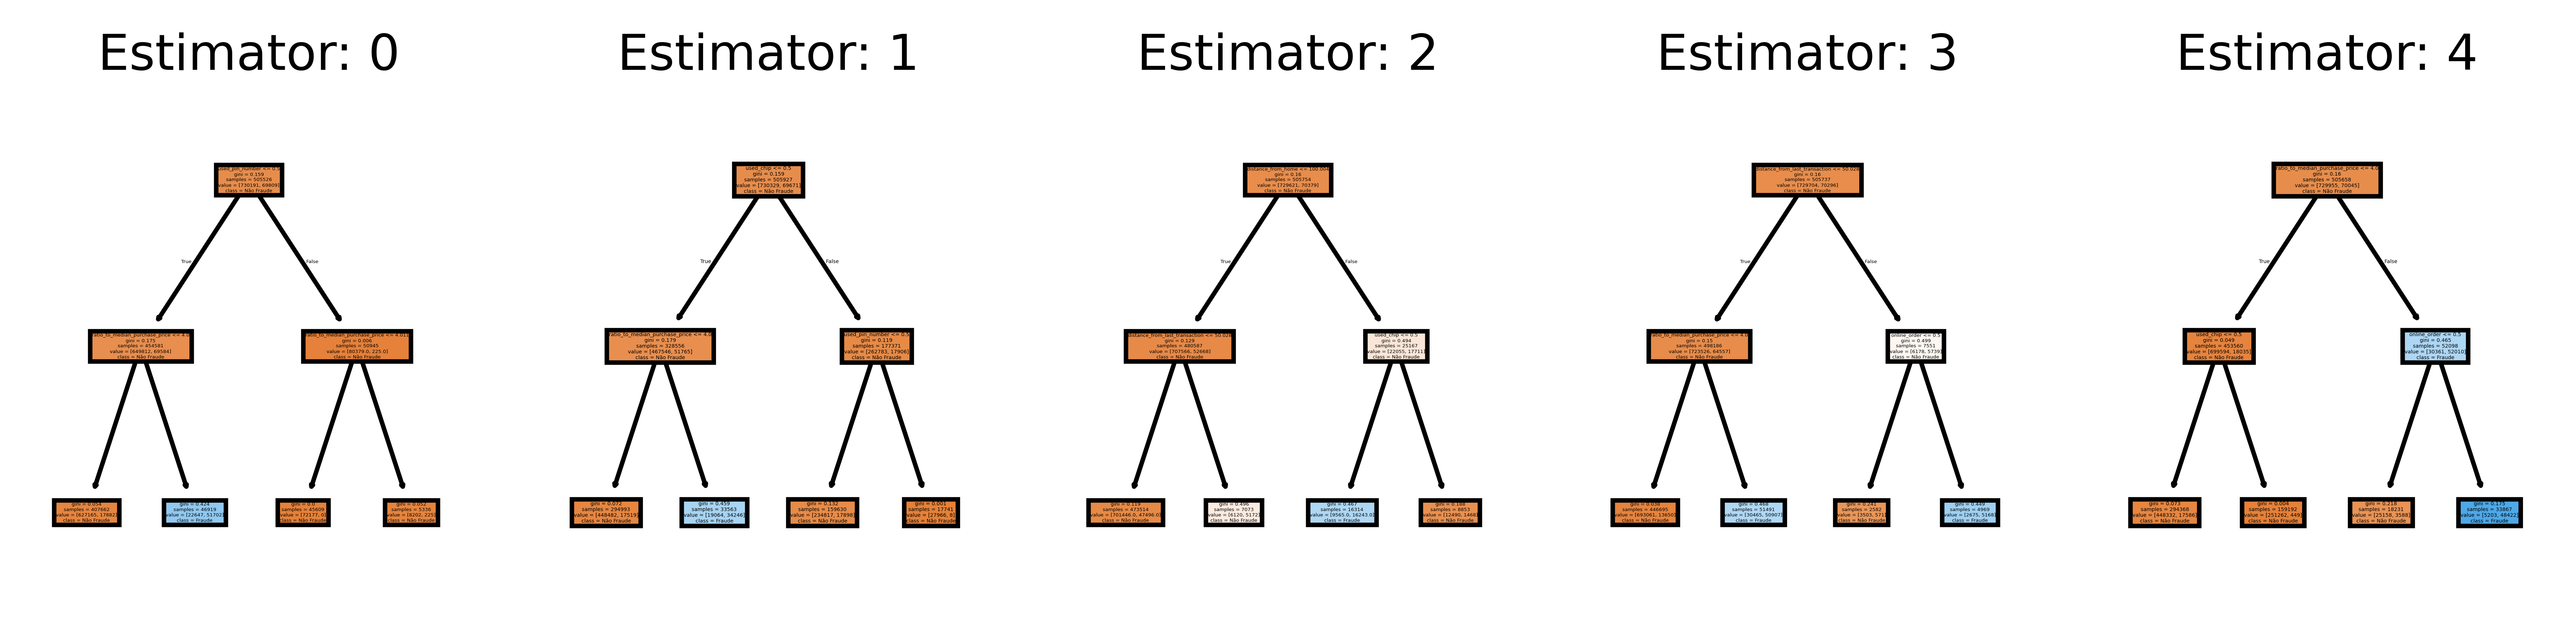

In [67]:
fig, axes = plt.subplots(nrows = 1,ncols = 5,figsize = (10,2), dpi=900)
for index in range(0, 5):
    tree.plot_tree(rf.estimators_[index],
                   feature_names = label_names,
                   class_names=class_names,
                   filled = True,
                   ax = axes[index]);

    axes[index].set_title('Estimator: ' + str(index), fontsize = 11)
fig.savefig('rf_5trees.png')

In [68]:
print(rf.score(x_train, y_train))
print(rf.score(x_test, y_test))

0.95321875
0.95339


Por quê?
* Se treino >> teste: pode ter overfitting
* Se ambos baixos: pode ter underfitting
* Se próximos: tende a generalizar melhor

In [71]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, cohen_kappa_score

In [72]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predito))

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98    182519
         1.0       0.90      0.69      0.78     17481

    accuracy                           0.97    200000
   macro avg       0.94      0.84      0.88    200000
weighted avg       0.97      0.97      0.96    200000



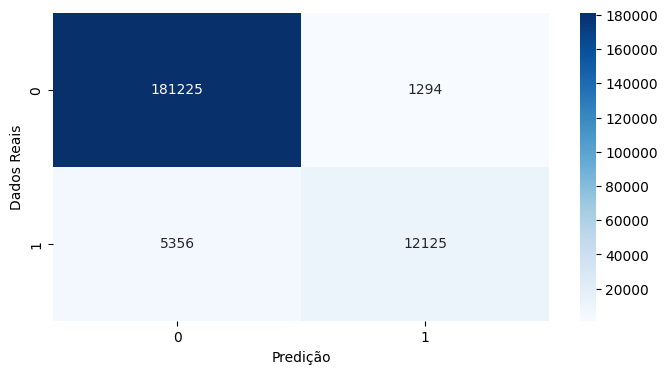

In [73]:
matriz_confusao = confusion_matrix(y_test, y_predito)
plt.figure(figsize = (8, 4))
sns.heatmap(matriz_confusao, annot = True, fmt="d",cmap = "Blues")
plt.xlabel("Predição");
plt.ylabel("Dados Reais");